
# Note Detection 
Sophie Lin

(uses Alexandre R.J. Francois' Chroma and Chromagrams)


In [119]:
import sys
print(sys.executable)

/Users/sophielin/miniforge3/envs/noFFT_env/bin/python


In [120]:
import numpy as np
from matplotlib import colormaps as mcm
import matplotlib.pyplot as plt
import librosa
import soundfile as sf

from noFFT_utils import log_frequencies, alphas_heuristic, resonate_wrapper

# Audio Data Load and Visualization

(841728,)
float64


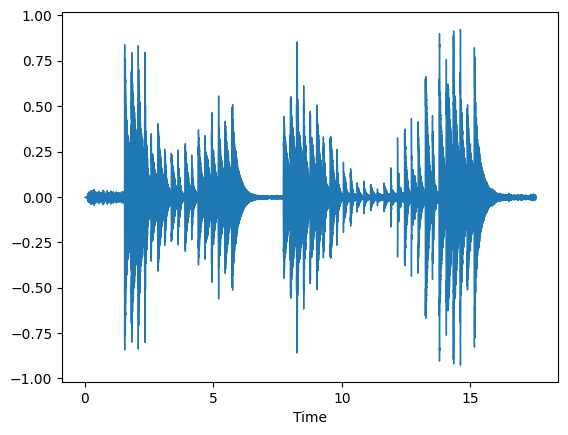

In [121]:
#https://librosa.org/doc/main/recordings.html


# y, sr = sf.read(librosa.ex("brahms"), frames=100000)
filepath = "../xylo_scale.wav"
y, sr = sf.read(filepath)
# y, sr = sf.read(librosa.ex("sweetwaltz"))
# y, sr = sf.read(librosa.ex("libri1"))
# y, sr = sf.read(librosa.ex("libri2"))
# y, sr = sf.read(librosa.ex("libri3"))
# y, sr = sf.read(librosa.ex("robin"))

librosa.display.waveshow(y, sr=sr)
print(y.shape)
print(y.dtype)

# float_y = np.array(y, dtype=np.float32)
# print(float_y.dtype)

# Getting Ground Truth Boundaries from Audio

[  6144   8704  11264  33792  73728  86016  98816 111104 123392 135680
 148480 161280 173568 186368 199168 210944 223744 236032 248832 261120
 273920 370176 382976 394752 407552 420352 432128 444928 457216 470016
 482304 495616 507904 520704 533504 546304 558592 570880 583680 596480
 609280 622080 635392 648704 660992 674304 687104 699904 713216 726528
 837632]


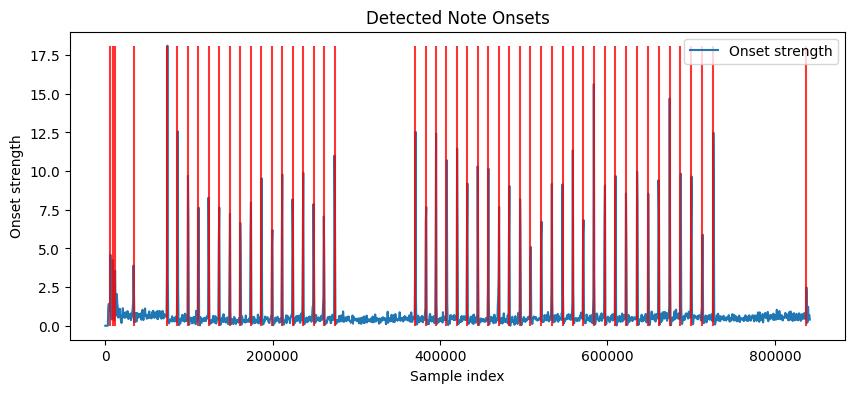

In [122]:
#gets onset strengths
onsets = librosa.onset.onset_strength(y=y, sr=sr)

#get the frames of where the strongest onsets are 
onset_frames = librosa.onset.onset_detect(onset_envelope=onsets, sr=sr)
onset_samples = librosa.frames_to_samples(onset_frames) #changes frames to samples (since x-axis in samples)

#print(onset_frames)
print(onset_samples)

#plot
plt.figure(figsize=(10, 4))
plt.plot(librosa.frames_to_samples(np.arange(len(onsets))), onsets, label='Onset strength')
peaks = onsets[onsets>5]
plt.vlines(onset_samples, 0, max(onsets), color='r', alpha=0.8)
plt.xlabel('Sample index')
plt.ylabel('Onset strength')
plt.title('Detected Note Onsets')
plt.legend()

In [123]:
peaks = onsets[onsets>5]
#17 +29
print(peaks)



[18.10450549 12.5661511   9.69308992  6.85438652  7.47222487  7.63055714
  8.28341111  5.36293051  7.63936224  7.23469757  6.64645263  5.90644071
  7.96593437  9.52335106  5.25608266  6.18892577  9.78657382  8.1713331
  5.77079797  9.8846663   7.87188686  7.06366525 11.0064884   6.82103161
 12.53970035  6.74162994  7.67032176 12.41999778 10.69584859 11.45760359
  6.73526102  5.51777943  9.199242   10.30926742 10.1555621   7.67851312
  5.58561819  9.03631969  8.18177658  5.86517461  5.08946644  5.68661552
  6.7263624   9.17007934  9.14261903 11.34959675  5.91147036  6.83569352
 15.62543364  6.87537006  9.07336451  7.81064149  9.67734594  8.55099053
  5.35300182  9.96258551  7.80945115  8.55022736  9.40796931  7.24393874
 14.69216191  6.01421978  9.82417773  6.2078511   9.64464739  5.60250117
  5.88695782 12.47913809  7.81314373]


### Cleaned Up (Hardcoded) Ground Truth Boundaries
Manually put some of the missing boundaries

[18.10450549 12.5661511   9.69308992  6.85438652  7.47222487  7.63055714
  8.28341111  5.36293051  7.63936224  7.23469757  6.64645263  5.90644071
  7.96593437  9.52335106  5.25608266  6.18892577  9.78657382  8.1713331
  5.77079797  9.8846663   7.87188686  7.06366525 11.0064884   6.82103161
 12.53970035  6.74162994  7.67032176 12.41999778 10.69584859 11.45760359
  6.73526102  5.51777943  9.199242   10.30926742 10.1555621   7.67851312
  5.58561819  9.03631969  8.18177658  5.86517461  5.08946644  5.68661552
  6.7263624   9.17007934  9.14261903 11.34959675  5.91147036  6.83569352
 15.62543364  6.87537006  9.07336451  7.81064149  9.67734594  8.55099053
  5.35300182  9.96258551  7.80945115  8.55022736  9.40796931  7.24393874
 14.69216191  6.01421978  9.82417773  6.2078511   9.64464739  5.60250117
  5.88695782 12.47913809  7.81314373]
[  6144   8704  11264  33792  73728  86016  98816 111104 123392 135680
 148480 161280 173568 186368 199168 210944 223744 236032 248832 261120
 273920 370176 382

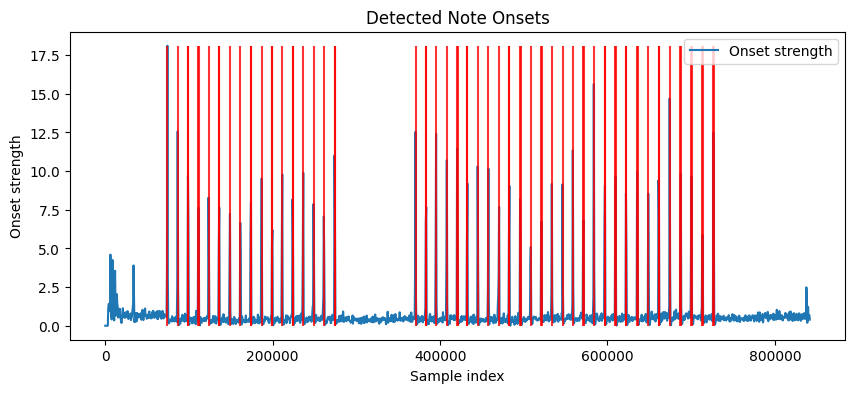

In [124]:
#print(y.shape)

#gets onsets strengths
onsets = librosa.onset.onset_strength(y=y, sr=sr)

#only accept the peaks (where the notes actually are)
peaks = onsets[onsets>5] #uses a hard-coded threshold of 5 onset strength 
print(peaks) 

peak_frames = np.where(onsets > 5)[0]
peak_samples = librosa.frames_to_samples(peak_frames)
#testing out different peak detection methods forms 
onset_frames = librosa.onset.onset_detect(onset_envelope=onsets, sr=sr)
#print(onsets, onsets.shape)
onset_samples = librosa.frames_to_samples(onset_frames)

#plot 
print(onset_samples)
plt.figure(figsize=(10, 4))
plt.plot(librosa.frames_to_samples(np.arange(len(onsets))), onsets, label='Onset strength')
plt.vlines(peak_samples, 0, max(onsets), color='r', alpha=0.8)
plt.xlabel('Sample index')
plt.ylabel('Onset strength')
plt.title('Detected Note Onsets')
plt.legend()
print(len(onset_samples))

#print(onset_frames)


46


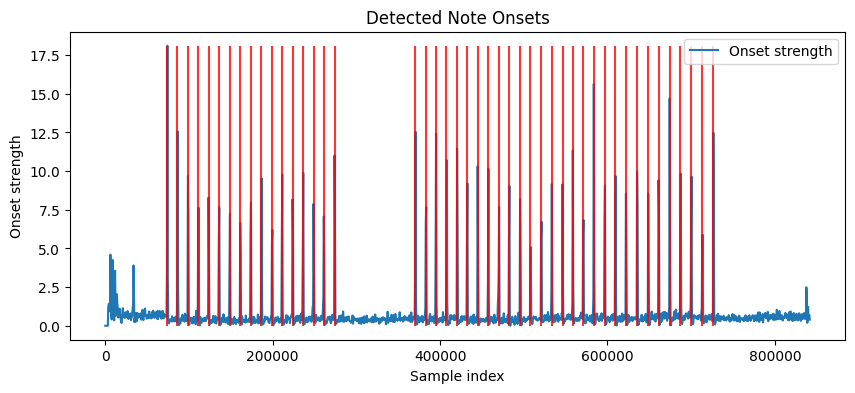

In [125]:
#delete duplicates
hardcoded_notes = [  73728, 86016, 98816, 111104, 123392, 135680,
    148480, 161280, 173568, 186368, 199168, 210944, 223744, 236032, 248832, 261120,
    273920, 370176, 382976, 394752, 407552, 420352, 432128, 444928, 457216, 470016,
    482304, 495616, 507904, 520704, 533504, 546304, 558592, 570880, 583680, 596480,
    609280, 622080, 635392, 648704, 660992, 674304, 687104, 699904, 713216, 726528]

print(len(hardcoded_notes))
plt.figure(figsize=(10, 4))
plt.plot(librosa.frames_to_samples(np.arange(len(onsets))), onsets, label='Onset strength')
plt.vlines(hardcoded_notes, 0, max(onsets), color='r', alpha=0.8)
plt.xlabel('Sample index')
plt.ylabel('Onset strength')
plt.title('Detected Note Onsets')
plt.legend()


#print(onset_frames)

# Create Chromas of the audio

In [126]:
#set variables

fmin = 32.70
n_freqs = 84
freqs_per_octave = 12
frequencies = log_frequencies(fmin=fmin, n_freqs=n_freqs, freqs_per_octave=freqs_per_octave)
alphas = alphas_heuristic(frequencies, sr=sr, k=1)
hop_length = 1
dhl = 512 # hop length for display

print(frequencies)

[  32.7          34.64444319   36.70450898   38.88707266   41.19941833
   43.64926323   46.24478349   48.99464141   51.9080144    54.99462556
   58.26477617   61.72938005   65.4          69.28888637   73.40901796
   77.77414532   82.39883666   87.29852646   92.48956698   97.98928283
  103.8160288   109.98925112  116.52955233  123.4587601   130.8
  138.57777274  146.81803592  155.54829064  164.79767333  174.59705293
  184.97913396  195.97856566  207.6320576   219.97850223  233.05910467
  246.9175202   261.6         277.15554548  293.63607184  311.09658128
  329.59534665  349.19410585  369.95826792  391.95713131  415.26411519
  439.95700446  466.11820933  493.8350404   523.2         554.31109097
  587.27214368  622.19316257  659.1906933   698.3882117   739.91653583
  783.91426262  830.52823039  879.91400892  932.23641866  987.67008079
 1046.4        1108.62218194 1174.54428735 1244.38632514 1318.38138661
 1396.7764234  1479.83307167 1567.82852524 1661.05646078 1759.82801784
 1864.4728373

(841728, 84) float64


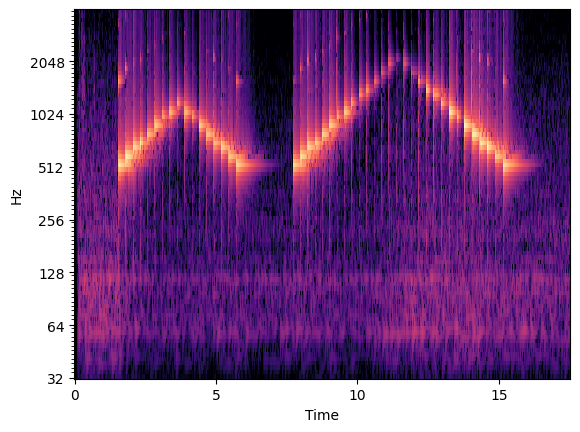

In [127]:
#compute a resonator bank outputs from input
R = resonate_wrapper(y=y, sr=sr, frequencies=frequencies, alphas=alphas, hop_length=hop_length, output_type='powers')
print(R.shape, R.dtype)

R_db = librosa.power_to_db(R.T, ref=np.max)

# Single spectrogram
librosa.display.specshow(
    R_db[:, ::dhl],
    sr=sr,
    fmin = frequencies[0],
    hop_length=dhl,
    y_axis="cqt_hz",
    x_axis="time",
)


(841728, 84)
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [4.83015515e-08 6.46209050e-08 1.04947902e-07 ... 5.65488657e-13
  5.57871284e-12 1.80087092e-11]
 [4.83222428e-08 6.46464108e-08 1.04968571e-07 ... 5.42294332e-13
  5.50161750e-12 1.77833129e-11]
 [4.83429049e-08 6.46718656e-08 1.04989195e-07 ... 5.21242722e-13
  5.42457166e-12 1.75532931e-11]]


[Text(0.5, 1.0, 'Resonate Chromagram')]

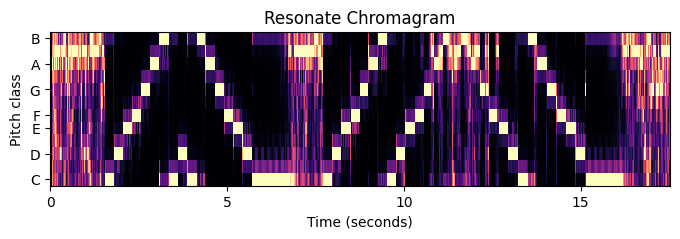

In [128]:
# Create chromagram (octave only)

K = R.copy()

print(R.shape)
print(R)

# print(K.shape)
# print(K)
# print(K[0].shape)
# print(K[10].shape)

numChroma = 12
numOctaves = int(K.shape[-1] / numChroma)
# print(numChroma, numOctaves)

C = K.reshape(K.shape[0], numOctaves, numChroma)
# print(C.shape)

C = C.sum(axis=1).T
# print(D.shape, D)

C = librosa.util.normalize(C, norm=np.inf, axis=-2)

# print(C)
# print(freqs[0:12])

# Single spectrogram
fig, ax = plt.subplots(figsize=(8, 2), dpi=100)
librosa.display.specshow(
    C[:,::dhl],
    sr=sr,
    hop_length=dhl,
    fmin = frequencies[0],
    bins_per_octave=12,
    y_axis="chroma",
    x_axis="s",
    ax=ax,
)
ax.set(title="Resonate Chromagram")

### Experimenting with no octaves, and using 128 note bins instead

minimum note:  8.175798915643707
(128, 1645)


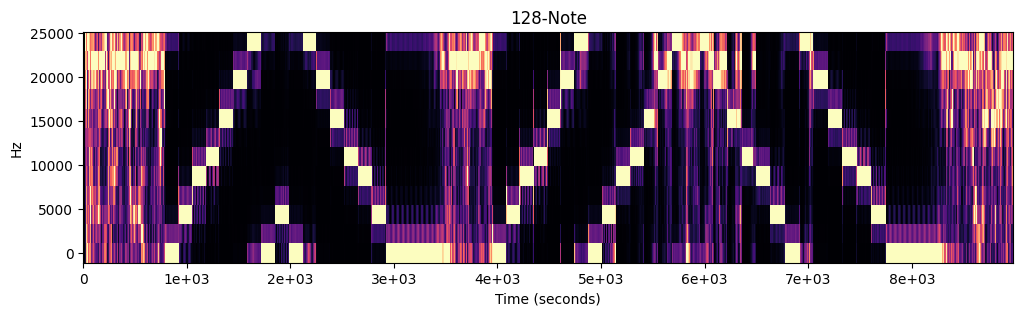

In [129]:
#only one octave, but switched to 128 bins (for 128 notes)

n_bins = 128           # total number of notes/bins
hop_length = dhl     
fmin = librosa.midi_to_hz(0) # lowest note
print(f"minimum note: ", fmin)

R = np.abs(librosa.cqt(
    y,
    sr=sr,
    hop_length=hop_length,
    fmin=fmin,
    n_bins=n_bins,
    bins_per_octave=12  # 12 notes in an octave
))

print(R.shape)
# Plot
fig, ax = plt.subplots(figsize=(12, 3), dpi=100)
librosa.display.specshow(
    C,
    sr=sr,
    hop_length=hop_length,
    y_axis="linear",  # each bin is a note, not chroma
    x_axis="s",
    ax=ax
)
ax.set(title="128-Note")
plt.show()

# per sample 

### 128 notes (measured in hz), not limited to one octave

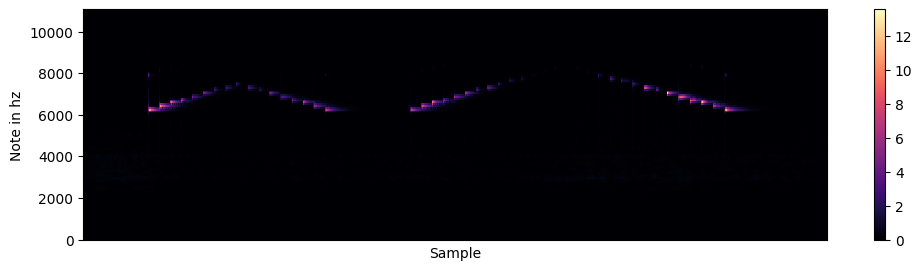

In [130]:
plt.figure(figsize=(12, 3))
librosa.display.specshow(
    R, 
    x_axis=None, # R is in time not samples 
    y_axis='linear',   # each row is one note, rahter than a chroma
    hop_length=hop_length,
    
)

plt.xlabel("Sample")
plt.ylabel("Note in hz")
plt.colorbar()
plt.show()

In [131]:
#check R is in 128 note vectors
print(R)
print(R.shape)

[[5.95884754e-03 6.06099812e-03 6.20168709e-03 ... 2.77730217e-03
  2.75712124e-03 2.73144852e-03]
 [5.55029723e-03 5.64232393e-03 5.73064305e-03 ... 1.16727188e-03
  1.21652872e-03 1.26476015e-03]
 [4.30651396e-03 4.41497047e-03 4.47573808e-03 ... 3.06055236e-03
  3.04042329e-03 3.01773559e-03]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 6.01497200e-05
  9.02287764e-06 1.75610144e-06]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 5.43543971e-05
  7.37764380e-06 3.75590340e-06]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.14151188e-04
  6.04162174e-06 6.12271303e-06]]
(128, 1645)


# Calculate Distances between Vectors

#### Euclidian Distance

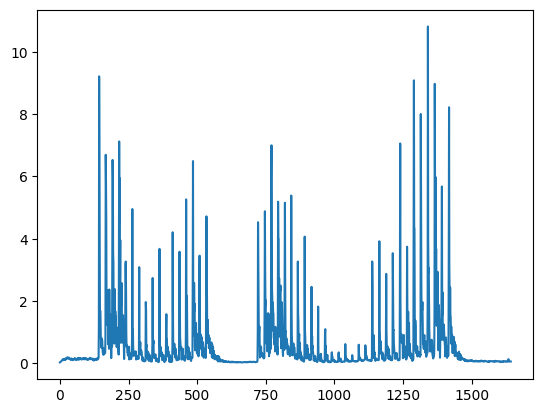

In [132]:
# plot differences between each vector 

distance = np.linalg.norm(R[:,1:]-R[:,:-1], axis = 0)
plt.plot(distance)

#### Cosine distance 
- Seems the cleanest out of all of them, peaks are more defined

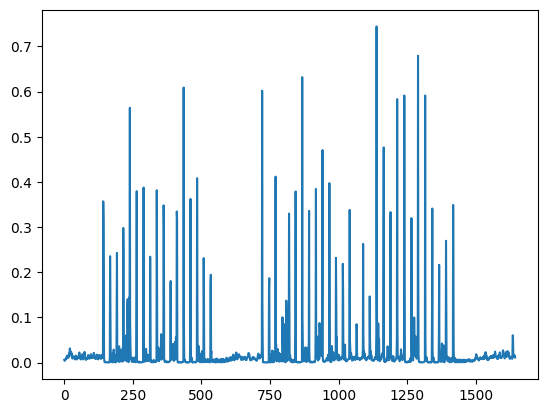

In [133]:
#seems cleanest
from scipy.spatial.distance import cosine
distance_cosine = [cosine(R[:,i], R[:,i+1]) for i in range(R.shape[1]-1)]
plt.plot(distance_cosine)

#### Manhattan Distance
- Lots of noise 

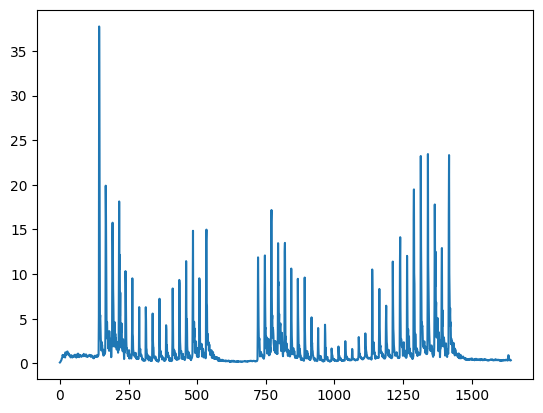

In [134]:
distance_manhattan = np.sum(np.abs(R[:,1:] - R[:,:-1]), axis=0)
plt.plot(distance_manhattan)

# Detecting boundaries from the filter bank

## Euclidian Distance

### Experimenting with different find_peaks thresholds 

Used these exact numbers for clean up (hardcoding) later

[ 77824  78848  80896  81920 120320 121344 124928 126464 127488 129024
 130048 131072 138752 140288 141312 142848 143872 145408 150016 151552
 161792 163328 164864 166400 167424 174592 176640 178176 187904 189952
 191488 193024 199680 201216 202240 205312 211968 213504 214528 215552
 217088 226304 227840 229376 231936 233472 239616 241664 256512 262144
 264192 265728 266752 269312 271360 277504 279040 280064 281088 282624
 284160 285696 287232 288768 289792 291328 292352 293888 295424 296960
 374272 375296 377344 378368 379904 399872 402944 404480 405504 422912
 423936 425984 427520 430080 435712 437248 440320 441856 446464 447488
 449024 450048 451072 459776 461312 462336 464384 465408 470528 471552
 474624 476160 484352 485888 486912 496128 497664 498688 507392 508416
 520192 532480 545280 557568 569856 571904 584192 585728 587264 598016
 599552 601600 603136 611328 613888 614912 615936 625152 626688 628224
 636928 638976 640512 641536 642560 644096 645632 652800 655360 665600
 66662

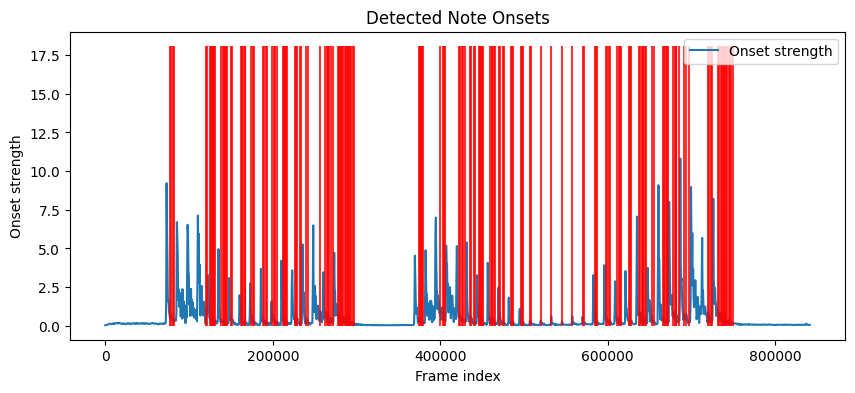

In [135]:
##### Low Threshold #####
from scipy.signal import find_peaks

#get actual boundaires for audio 
peaks = find_peaks(distance,height=(0.2,1))[0]*dhl
x_samples = np.arange(len(distance)) * dhl


print(peaks, len(peaks))
#get the frames
onset_frames = librosa.onset.onset_detect(onset_envelope=onsets, sr=sr)
#print(onsets, onsets.shape)
print(onsets)
plt.figure(figsize=(10, 4))
plt.plot(x_samples, distance, label='Onset strength')
plt.vlines(peaks, 0, max(onsets), color='r', alpha=0.8)
plt.xlabel('Frame index')
plt.ylabel('Onset strength')
plt.title('Detected Note Onsets')
plt.legend()

print(onset_frames)

[ 78848 120320 124928 129024 150016 161792 174592 187904 201216 211968
 213504 226304 239616 265728 266752 280064 281088 282624 284160 285696
 375296 405504 423936 425984 435712 437248 447488 461312 471552 496128
 532480 557568 569856 584192 598016 611328 640512 642560 645632 652800
 665600 666624 677888 680960 681984 691200 719360 722944 736256 737792] 50
[0.         0.         0.         ... 0.68991315 0.68881098 0.39603402]


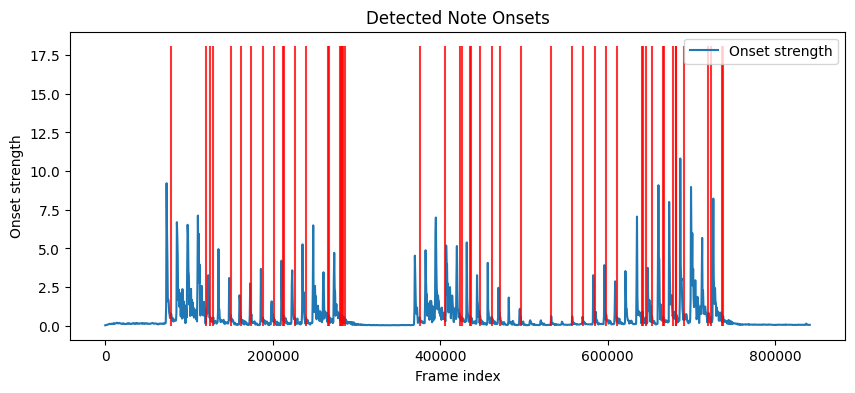

In [136]:
##### Medium Threshold #####
peaks = find_peaks(distance,height=(0.5,0.75))[0]*dhl

print(peaks, len(peaks))
print(onsets)
plt.figure(figsize=(10, 4))
plt.plot(x_samples, distance, label='Onset strength')
plt.vlines(peaks, 0, max(onsets), color='r', alpha=0.8)
plt.xlabel('Frame index')
plt.ylabel('Onset strength')
plt.title('Detected Note Onsets')
plt.legend()


[ 73216  85504  98304 110592 111616 112640 122880 135168 147968 185856
 210432 223232 235520 248320 260608 273408 369664 382464 394752 407040
 419840 431616 443904 456704 582656 595968 621056 634880 647680 660480
 673280 686592 688128 699392 700928 701952 712704 726016] 38
[0.         0.         0.         ... 0.68991315 0.68881098 0.39603402]


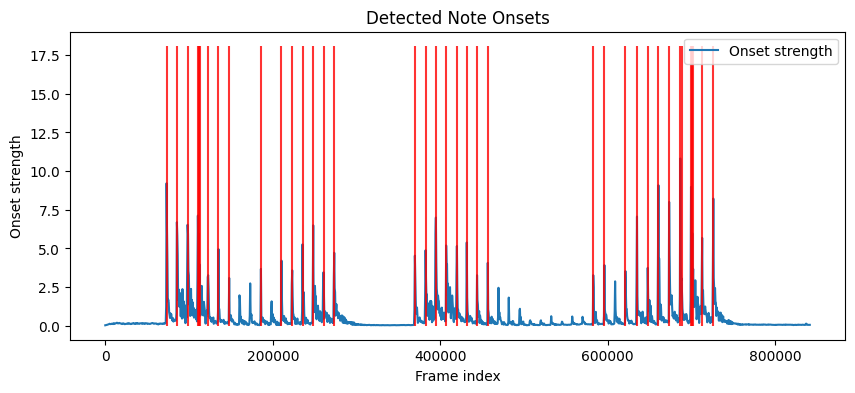

In [137]:
##### High Threshold #####
peaks = find_peaks(distance,height=3)[0]*dhl

print(peaks, len(peaks))
#get the frames
onset_frames = librosa.onset.onset_detect(onset_envelope=onsets, sr=sr)
#print(onsets, onsets.shape)
print(onsets)
plt.figure(figsize=(10, 4))
plt.plot(x_samples, distance, label='Onset strength')
plt.vlines(peaks, 0, max(onsets), color='r', alpha=0.8)
plt.xlabel('Frame index')
plt.ylabel('Onset strength')
plt.title('Detected Note Onsets')
plt.legend()


### Hardcoded Peaks for Processed Audio from Filter Bank 
I tried to use the exact numbers (from the different thresholds), but had to manually add some in by using the visual graph

[ 73216  85504  98304 110592 111616 112640 122880 135168 147968 185856
 210432 223232 235520 248320 260608 273408 369664 382464 394752 407040
 419840 431616 443904 456704 582656 595968 621056 634880 647680 660480
 673280 686592 688128 699392 700928 701952 712704 726016]
46


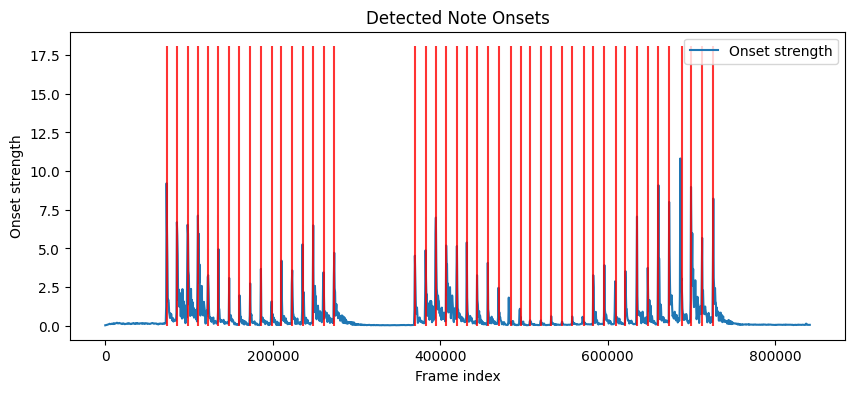

In [138]:
#hardcoded peaks 
print(peaks)
peaks_hardcoded = [
    73216, 85504, 98304, 110592, 122880, 135168, 147968, 160000, 173000, 185856, 199000,
    210432, 223232, 235520, 248320, 260608, 273408, 369664, 382464, 394752, 407040,
    419840, 431616, 443904, 456704, 
    #quiet parts
      470000, 484352, 496128,  507392, 
    520192, 532480, 545280, 557568,  571904, 
    
    582656, 595968, 610000, 621056, 634880, 647680, 660480,
    673280, 688128, 699392,  712704, 726016
]
print(len(peaks_hardcoded))
x_samples = np.arange(len(distance)) * dhl

plt.figure(figsize=(10, 4))
plt.plot(x_samples, distance, label='Onset strength')
plt.vlines(peaks_hardcoded, 0, max(onsets), color='r', alpha=0.8)
plt.xlabel('Frame index')
plt.ylabel('Onset strength')
plt.title('Detected Note Onsets')
plt.legend()



## Cosine Distance

### Calculate Boundaries for Cosine Distance on processed audio 

[ 72704  85504  98304 110080 122368 135168 147968 160256 172544 185344
 209920 222720 235520 247808 260096 369152 394240 419328 431616 443904
 456704 469504 481792 494592 506880 519680 532480 557568 582656 595968
 608768 621056 634368 647680 659968 673280 686592 699392 712192 725504] 40


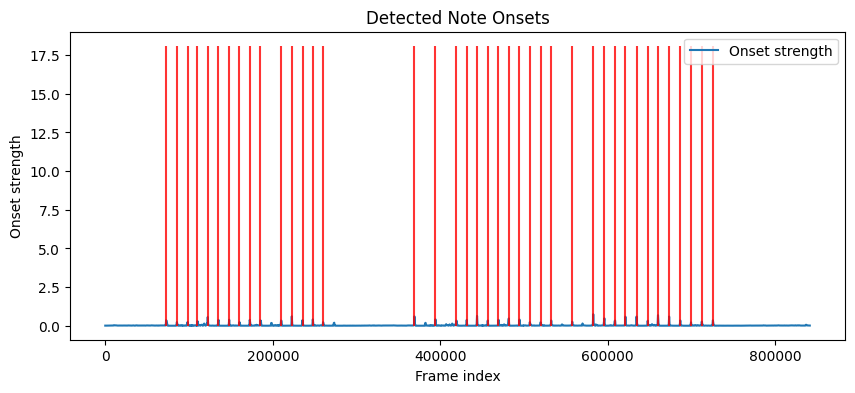

In [139]:
#boundaries of cosine
#cleaner, less missing peaks (could also be peak finding alg)
peaks_cosine = find_peaks(distance_cosine,height=(0.2,1))[0]*dhl
x_samples_cosine = np.arange(len(distance_cosine)) * dhl


print(peaks_cosine, len(peaks_cosine))
#get the frames
onset_frames1 = librosa.onset.onset_detect(onset_envelope=onsets, sr=sr)
#print(onsets, onsets.shape)
plt.figure(figsize=(10, 4))
plt.plot(x_samples_cosine, distance_cosine, label='Onset strength')
plt.vlines(peaks_cosine, 0, max(onsets), color='r', alpha=0.8)
plt.xlabel('Frame index')
plt.ylabel('Onset strength')
plt.title('Detected Note Onsets')
plt.legend()


### Hardcoded Cosine

Only added 6 lines in 


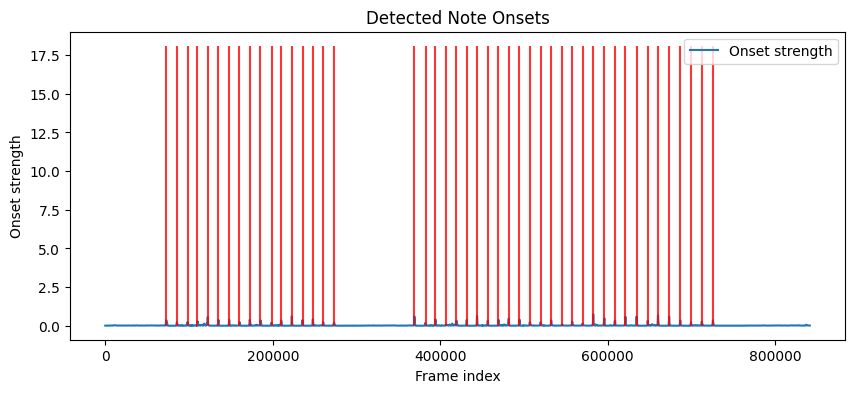

In [140]:
#clean up the cosine (input a 6 lines) 
hardcoded_cosine = [ 72704, 85504, 98304, 110080, 122368, 135168, 147968, 160256, 172544, 185344, 199500,
    209920, 222720, 235520, 247808, 260096, 273000,
    #second scale
    369152, 383000, 394240, 407000 ,419328, 431616, 443904, 456704, 469504, 481792, 494592, 506880, 519680, 532480, 545000,557568, 570000, 582656, 595968,
    608768, 621056, 634368, 647680, 659968, 673280, 686592, 699392, 712192, 725504]


plt.figure(figsize=(10, 4))
plt.plot(x_samples_cosine, distance_cosine, label='Onset strength')
plt.vlines(hardcoded_cosine, 0, max(onsets), color='r', alpha=0.8)
plt.xlabel('Frame index')
plt.ylabel('Onset strength')
plt.title('Detected Note Onsets')
plt.legend()



## Manhattan Distance 
(didn't clean up)

[  5120   7680   9216  18432  20480  21504  24064  25600  27136  28160
  31232  35328  36352  37888  39936  41984  43008  45568  47104  48640
  51712  54784  56832  58880  60928  62976  64000  65024  66048  67072
  69632 130048 131584 142848 143872 145408 151552 154624 156160 157696
 163328 164864 166400 167424 168960 170496 176640 178176 179712 180736
 181760 183296 189952 191488 192512 195072 196096 202240 205312 206848
 208384 217088 218624 219648 220672 227840 231936 233472 241664 244224
 287232 288768 289792 291328 292864 293888 295424 296960 298496 300032
 301568 302592 305152 306688 308224 309760 311296 313856 315392 316928
 317952 318976 321024 324096 325120 326144 329216 331776 333312 334848
 336896 337920 341504 343552 345088 348160 349184 350208 352256 353280
 354816 355840 356864 357888 361984 364544 366080 367104 376320 377344
 378368 379904 440320 442368 449024 450048 451072 454144 464384 465408
 466944 474624 476160 485888 486912 489472 491008 492032 493056 497664
 49920

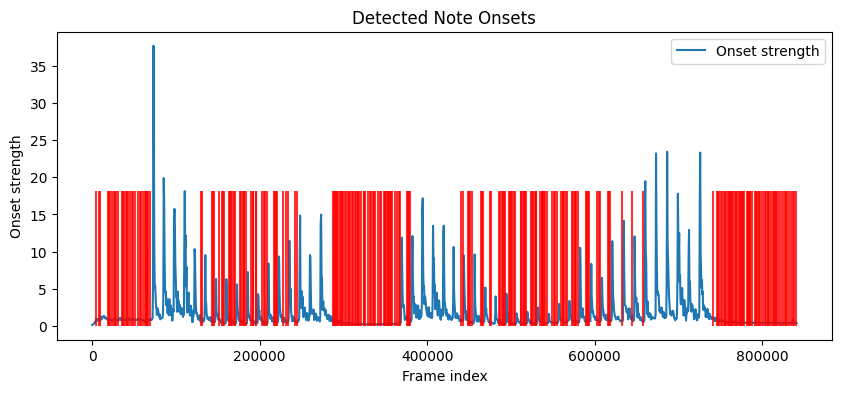

In [141]:
#boundaries of manhattan 
peaks_manhattan = find_peaks(distance_manhattan,height=(0.2,1))[0]*dhl
x_samples_manhattan = np.arange(len(distance_manhattan)) * dhl


print(peaks_manhattan, len(peaks_manhattan))
#get the frames
onset_frames2 = librosa.onset.onset_detect(onset_envelope=onsets, sr=sr)
#print(onsets, onsets.shape)

plt.figure(figsize=(10, 4))
plt.plot(x_samples_manhattan, distance_manhattan, label='Onset strength')
plt.vlines(peaks_manhattan, 0, max(onsets), color='r', alpha=0.8)
plt.xlabel('Frame index')
plt.ylabel('Onset strength')
plt.title('Detected Note Onsets')
plt.legend()


# Calculate Average of Boundaries Differences 

##### Used Diffrence and Root Square Mean Error

### Euclidian Distance

In [142]:
actual_boundaries = np.array(hardcoded_notes)
notes_boundaries = np.array(peaks_hardcoded)
#print(len(peaks_hardcoded))

#caclculate difference
difference = actual_boundaries-notes_boundaries

#calculate rmse
rmse = np.sqrt(1/(len(actual_boundaries))*np.sum(np.square(difference)))
print(difference)
print(rmse)

[  512   512   512   512   512   512   512  1280   568   512   168   512
   512   512   512   512   512   512   512     0   512   512   512  1024
   512    16 -2048  -512   512   512  1024  1024  1024 -1024  1024   512
  -720  1024   512  1024   512  1024 -1024   512   512   512]
734.1091021864826


### Cosine Distance

In [143]:
#calculate boundaries for cosine 
actual_boundaries = np.array(hardcoded_notes)
notes_boundaries_cosine = np.array(hardcoded_cosine)
#print(len(peaks_hardcoded))

#caclculate difference
difference1 = actual_boundaries-notes_boundaries_cosine

#calculate rmse
rmse1 = np.sqrt(1/(len(actual_boundaries))*np.sum(np.square(difference1)))
print(difference1)
print(rmse1)


[1024  512  512 1024 1024  512  512 1024 1024 1024 -332 1024 1024  512
 1024 1024  920 1024  -24  512  552 1024  512 1024  512  512  512 1024
 1024 1024 1024 1304 1024  880 1024  512  512 1024 1024 1024 1024 1024
  512  512 1024 1024]
868.1528617152326


# Get the average 128-dimensional vector between the two boundaries (actual and measured)

## Average of every consecutive boundary (boundary lines only)

##### Euclidian 

In [144]:
print("shape of R: "+ str(R.shape))

#get columns that correspond to boundaries 
actual_boundaries_frame = actual_boundaries/dhl
print("retrive all boundaries(column) from the actual notes:" + str(actual_boundaries_frame))
actual_columns = np.array([R[:,int(col)] for col in actual_boundaries_frame]) #R is by frame? 
#clean up so not hardcode 512 btu have framerate var

#print(len(actual_columns), len(actual_columns[0]))
print("shape of boundaries vectors: " + str(actual_columns.shape))

#get the avg between each consecutive pair of vectors (columns)
avg_columns_actual = (actual_columns[:-1, :] + actual_columns[1:, :] ) / 2
print("After gettng the average each starting vector: " + str(avg_columns_actual.shape))

print("cosine columns: " + str(avg_columns_actual))

shape of R: (128, 1645)
retrive all boundaries(column) from the actual notes:[ 144.  168.  193.  217.  241.  265.  290.  315.  339.  364.  389.  412.
  437.  461.  486.  510.  535.  723.  748.  771.  796.  821.  844.  869.
  893.  918.  942.  968.  992. 1017. 1042. 1067. 1091. 1115. 1140. 1165.
 1190. 1215. 1241. 1267. 1291. 1317. 1342. 1367. 1393. 1419.]
shape of boundaries vectors: (46, 128)
After gettng the average each starting vector: (45, 128)
cosine columns: [[0.02054924 0.02326257 0.01546882 ... 0.00305213 0.00202636 0.00145859]
 [0.01649265 0.01699236 0.01183747 ... 0.00068672 0.00064012 0.00055651]
 [0.01059313 0.00826745 0.00818061 ... 0.0004325  0.00030531 0.00054487]
 ...
 [0.00745634 0.00966214 0.01274979 ... 0.00084834 0.00075961 0.00086924]
 [0.00454116 0.00420561 0.00795751 ... 0.00066684 0.0006843  0.0007554 ]
 [0.00349917 0.00117234 0.00420125 ... 0.0006434  0.00042464 0.00076027]]


#### Cosine

In [145]:
print("shape of R: "+ str(R.shape))

#get columns that correspond to boundaries 
boundaries_frame_cosine = notes_boundaries_cosine/dhl

print("retrive all boundaries(column) from the actual notes:" + str(boundaries_frame_cosine))
cosine_columns = np.array([R[:,int(col)] for col in boundaries_frame_cosine]) #R is by frame? 
#clean up so not hardcode 512 btu have framerate var

#print(len(actual_columns), len(actual_columns[0]))
print("shape of boundaries vectors: " + str(cosine_columns.shape))

#get the avg between each consecutive pair of vectors (columns)
avg_cosine_columns = (cosine_columns[:-1, :] + cosine_columns[1:, :] ) / 2
print("After gettng the average each starting vector: " + str(avg_cosine_columns.shape))

print("cosine columns: " + str(avg_cosine_columns))

shape of R: (128, 1645)
retrive all boundaries(column) from the actual notes:[ 142.         167.         192.         215.         239.
  264.         289.         313.         337.         362.
  389.6484375  410.         435.         460.         484.
  508.         533.203125   721.         748.046875   770.
  794.921875   819.         843.         867.         892.
  917.         941.         966.         990.        1015.
 1040.        1064.453125  1089.        1113.28125   1138.
 1164.        1189.        1213.        1239.        1265.
 1289.        1315.        1341.        1366.        1391.
 1417.       ]
shape of boundaries vectors: (46, 128)
After gettng the average each starting vector: (45, 128)
cosine columns: [[2.06094180e-02 2.34259420e-02 1.55921751e-02 ... 1.27595215e-04
  1.20896962e-04 1.23162410e-04]
 [1.67157896e-02 1.73217577e-02 1.20023105e-02 ... 1.08256507e-02
  1.12190533e-02 1.24107185e-02]
 [1.09067849e-02 8.76569482e-03 8.36370334e-03 ... 1.07785857e-02
 

## Average Sum of All Cectors in Between Each Pair of Consecutive Boundary Vectors 

In [146]:
print(R.shape)

(128, 1645)


In [147]:
#testing my formula 

# exclusive of ending boundary line

#boundary lines and our 128 bin note vectors for every sample
boundaries = [0, 2, 4]
data = np.array([[10, 11, 12], [20, 21, 22], [30, 31, 32], [40, 41, 42], [50, 51, 52]]).T
print(data)
#loop through all boundaries to get the samples in between each 
for boundary in range(1, len(boundaries)):
    print(boundaries[boundary-1], boundaries[boundary])
    print(data[:, boundaries[boundary-1]:boundaries[boundary]])

    print(np.sum(data[:, boundaries[boundary-1]:boundaries[boundary]], axis = 1))
    print()

#Expected answer 
print("Expected Answer: [30, 32, 34], [70, 72, 74]")

[[10 20 30 40 50]
 [11 21 31 41 51]
 [12 22 32 42 52]]
0 2
[[10 20]
 [11 21]
 [12 22]]
[30 32 34]

2 4
[[30 40]
 [31 41]
 [32 42]]
[70 72 74]

Expected Answer: [30, 32, 34], [70, 72, 74]


### Euclidian 

In [148]:
print(R)
print(R.shape)

[[5.95884754e-03 6.06099812e-03 6.20168709e-03 ... 2.77730217e-03
  2.75712124e-03 2.73144852e-03]
 [5.55029723e-03 5.64232393e-03 5.73064305e-03 ... 1.16727188e-03
  1.21652872e-03 1.26476015e-03]
 [4.30651396e-03 4.41497047e-03 4.47573808e-03 ... 3.06055236e-03
  3.04042329e-03 3.01773559e-03]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 6.01497200e-05
  9.02287764e-06 1.75610144e-06]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 5.43543971e-05
  7.37764380e-06 3.75590340e-06]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.14151188e-04
  6.04162174e-06 6.12271303e-06]]
(128, 1645)


In [149]:
print("shape of R: "+ str(R.shape))

#get columns that correspond to boundaries 
actual_boundaries_frame = actual_boundaries/dhl

#add ending (last frame) 
actual_boundaries_frame = list(np.append(actual_boundaries_frame, R.shape[1]-1).astype(int))

print("retrive all boundaries(column) from the actual notes:" + str(actual_boundaries_frame))
actual_columns = np.array([R[:,int(col)] for col in actual_boundaries_frame]) #R is by frame? 

#print(len(actual_columns), len(actual_columns[0]))
print("shape of boundaries vectors: " + str(actual_columns.shape))

#get the avg between each consecutive pair of vectors (columns)
avg_columns_actual = np.empty((128, 0))
print(actual_columns.shape)
for boundary in range(1, len(actual_boundaries_frame)):
   prev_col = int(actual_boundaries_frame[boundary-1])
   cur_col = int(actual_boundaries_frame[boundary])
   #print(prev_col, cur_col)
   #print(np.sum(R[:, prev_col:cur_col], axis =1).shape)
   
   #get the avg of all the vectors in between cur boundary and prev
   col_avg= np.average(R[:, prev_col:cur_col], axis = 1).reshape(128,1)
   avg_columns_actual = np.concatenate((avg_columns_actual, col_avg), axis=1)

#changed from (128, 46) to (46, 128) - 46 notes and 128 bins each 
avg_columns_actual= avg_columns_actual.T

print("Shape after gettng the average each starting vector: " + str(avg_columns_actual.shape))

print("cosine columns: " + str(avg_columns_actual))

shape of R: (128, 1645)
retrive all boundaries(column) from the actual notes:[np.int64(144), np.int64(168), np.int64(193), np.int64(217), np.int64(241), np.int64(265), np.int64(290), np.int64(315), np.int64(339), np.int64(364), np.int64(389), np.int64(412), np.int64(437), np.int64(461), np.int64(486), np.int64(510), np.int64(535), np.int64(723), np.int64(748), np.int64(771), np.int64(796), np.int64(821), np.int64(844), np.int64(869), np.int64(893), np.int64(918), np.int64(942), np.int64(968), np.int64(992), np.int64(1017), np.int64(1042), np.int64(1067), np.int64(1091), np.int64(1115), np.int64(1140), np.int64(1165), np.int64(1190), np.int64(1215), np.int64(1241), np.int64(1267), np.int64(1291), np.int64(1317), np.int64(1342), np.int64(1367), np.int64(1393), np.int64(1419), np.int64(1644)]
shape of boundaries vectors: (47, 128)
(47, 128)
Shape after gettng the average each starting vector: (46, 128)
cosine columns: [[2.10253266e-02 2.37956298e-02 1.58096269e-02 ... 3.55608663e-04
  2.6

### Cosine

In [150]:
print("shape of R: "+ str(R.shape))

#get columns that correspond to boundaries 
cosine_boundaries_frame = notes_boundaries_cosine/dhl

#add ending (last frame) 
cosine_boundaries_frame = list(np.append(boundaries_frame_cosine, R.shape[1]-1).astype(int))

print("retrive all boundaries(column) from the actual notes:" + str(cosine_boundaries_frame))
cosine_columns = np.array([R[:,int(col)] for col in cosine_boundaries_frame]) #R is by frame? 

#print(len(actual_columns), len(actual_columns[0]))
print("shape of boundaries vectors: " + str(actual_columns.shape))

#get the avg between each consecutive pair of vectors (columns)
avg_columns_cosine = np.empty((128, 0))
print(avg_columns_cosine.shape)
for boundary in range(1, len(cosine_boundaries_frame)):
   prev_col = int(cosine_boundaries_frame[boundary-1])
   cur_col = int(cosine_boundaries_frame[boundary])
   #print(prev_col, cur_col)
   #print(np.sum(R[:, prev_col:cur_col], axis =1).shape)
   
   #get the avg of all the vectors in between cur boundary and prev
   col_avg= np.average(R[:, prev_col:cur_col], axis = 1).reshape(128,1)
   avg_columns_cosine = np.concatenate((avg_columns_cosine, col_avg), axis=1)

#changed from (128, 46) to (46, 128) - 46 notes and 128 bins each 
avg_columns_actual= avg_columns_actual.T

print("Shape after gettng the average each starting vector: " + str(avg_columns_actual.shape))

print("cosine columns: " + str(avg_columns_actual))

shape of R: (128, 1645)
retrive all boundaries(column) from the actual notes:[np.int64(142), np.int64(167), np.int64(192), np.int64(215), np.int64(239), np.int64(264), np.int64(289), np.int64(313), np.int64(337), np.int64(362), np.int64(389), np.int64(410), np.int64(435), np.int64(460), np.int64(484), np.int64(508), np.int64(533), np.int64(721), np.int64(748), np.int64(770), np.int64(794), np.int64(819), np.int64(843), np.int64(867), np.int64(892), np.int64(917), np.int64(941), np.int64(966), np.int64(990), np.int64(1015), np.int64(1040), np.int64(1064), np.int64(1089), np.int64(1113), np.int64(1138), np.int64(1164), np.int64(1189), np.int64(1213), np.int64(1239), np.int64(1265), np.int64(1289), np.int64(1315), np.int64(1341), np.int64(1366), np.int64(1391), np.int64(1417), np.int64(1644)]
shape of boundaries vectors: (47, 128)
(128, 0)
Shape after gettng the average each starting vector: (128, 46)
cosine columns: [[2.10253266e-02 1.67924850e-02 1.05183443e-02 ... 4.42511775e-03
  3.22

# Extra Chroma Code from the Original Notebook 

(12, 1645)
(12, 1645)


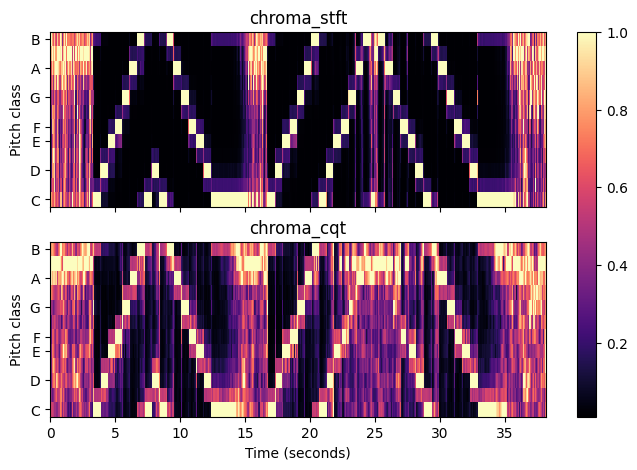

In [151]:
# Librosa Chroma

# librosa.feature.chroma_stft(*, y=None, sr=22050, S=None, norm=inf, n_fft=2048, hop_length=512, win_length=None, window='hann', center=True, pad_mode='constant', tuning=None, n_chroma=12, **kwargs)
chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=4096, hop_length=dhl)
print(chroma_stft.shape)

# librosa.feature.chroma_cqt(*, y=None, sr=22050, C=None, hop_length=512, fmin=None, norm=inf, threshold=0.0, tuning=None, n_chroma=12, n_octaves=7, window=None, bins_per_octave=36, cqt_mode='full')
chroma_cq = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=dhl, bins_per_octave=12)
print(chroma_cq.shape)

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(8, 5), dpi=100)
librosa.display.specshow(chroma_stft, hop_length=dhl, y_axis='chroma', x_axis='s', ax=ax[0])
ax[0].set(title='chroma_stft')
ax[0].label_outer()
img = librosa.display.specshow(chroma_cq, hop_length=dhl, y_axis='chroma', x_axis='s', ax=ax[1])
ax[1].set(title='chroma_cqt')
fig.colorbar(img, ax=ax)


48000 (1645, 128) (12, 128)


/var/folders/mr/f7bl28mx5h32nv4tqycy9src0000gn/T/ipykernel_30191/1299869317.py:14: UserWarning: Frequency axis exceeds Nyquist. Did you remember to set all spectrogram parameters in specshow?
  librosa.display.specshow(
/var/folders/mr/f7bl28mx5h32nv4tqycy9src0000gn/T/ipykernel_30191/1299869317.py:22: UserWarning: Adding colorbar to a different Figure <Figure size 800x500 with 3 Axes> than <Figure size 800x500 with 3 Axes> which fig.colorbar is called on.
  fig.colorbar(img, ax=[ax[0]])


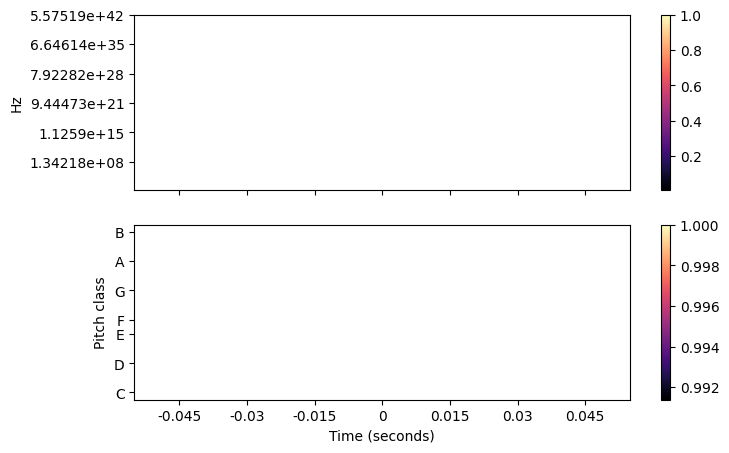

In [152]:
# Resonate Chroma

# S = np.abs(librosa.stft(y))**2
# S = np.abs(librosa.stft(y, n_fft=4096))**2
# chroma_stft = librosa.feature.chroma_stft(S=S, sr=sr, n_chroma=12, n_fft=4096)

chromaR = librosa.feature.chroma_cqt(C=R.T, sr=sr, bins_per_octave=12)

print(sr, R.T.shape, chromaR.shape)

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(8, 5), dpi=100)
# img = librosa.display.specshow(librosa.power_to_db(S, ref=np.max), y_axis='log', x_axis='time', ax=ax[0])
# img = librosa.display.specshow(librosa.power_to_db(R, ref=np.max), y_axis='log', x_axis='time', ax=ax[0])
librosa.display.specshow(
    librosa.power_to_db(R.T[:,::dhl], ref=np.max),
    sr=sr,
    hop_length=dhl,
    y_axis="cqt_hz",
    x_axis="s",
    ax=ax[0]
)
fig.colorbar(img, ax=[ax[0]])
ax[0].label_outer()

img = librosa.display.specshow(
    chromaR[:,::dhl],
    sr=sr,
    hop_length=dhl,
    y_axis='chroma',
    x_axis='s',
    ax=ax[1])
fig.colorbar(img, ax=[ax[1]])


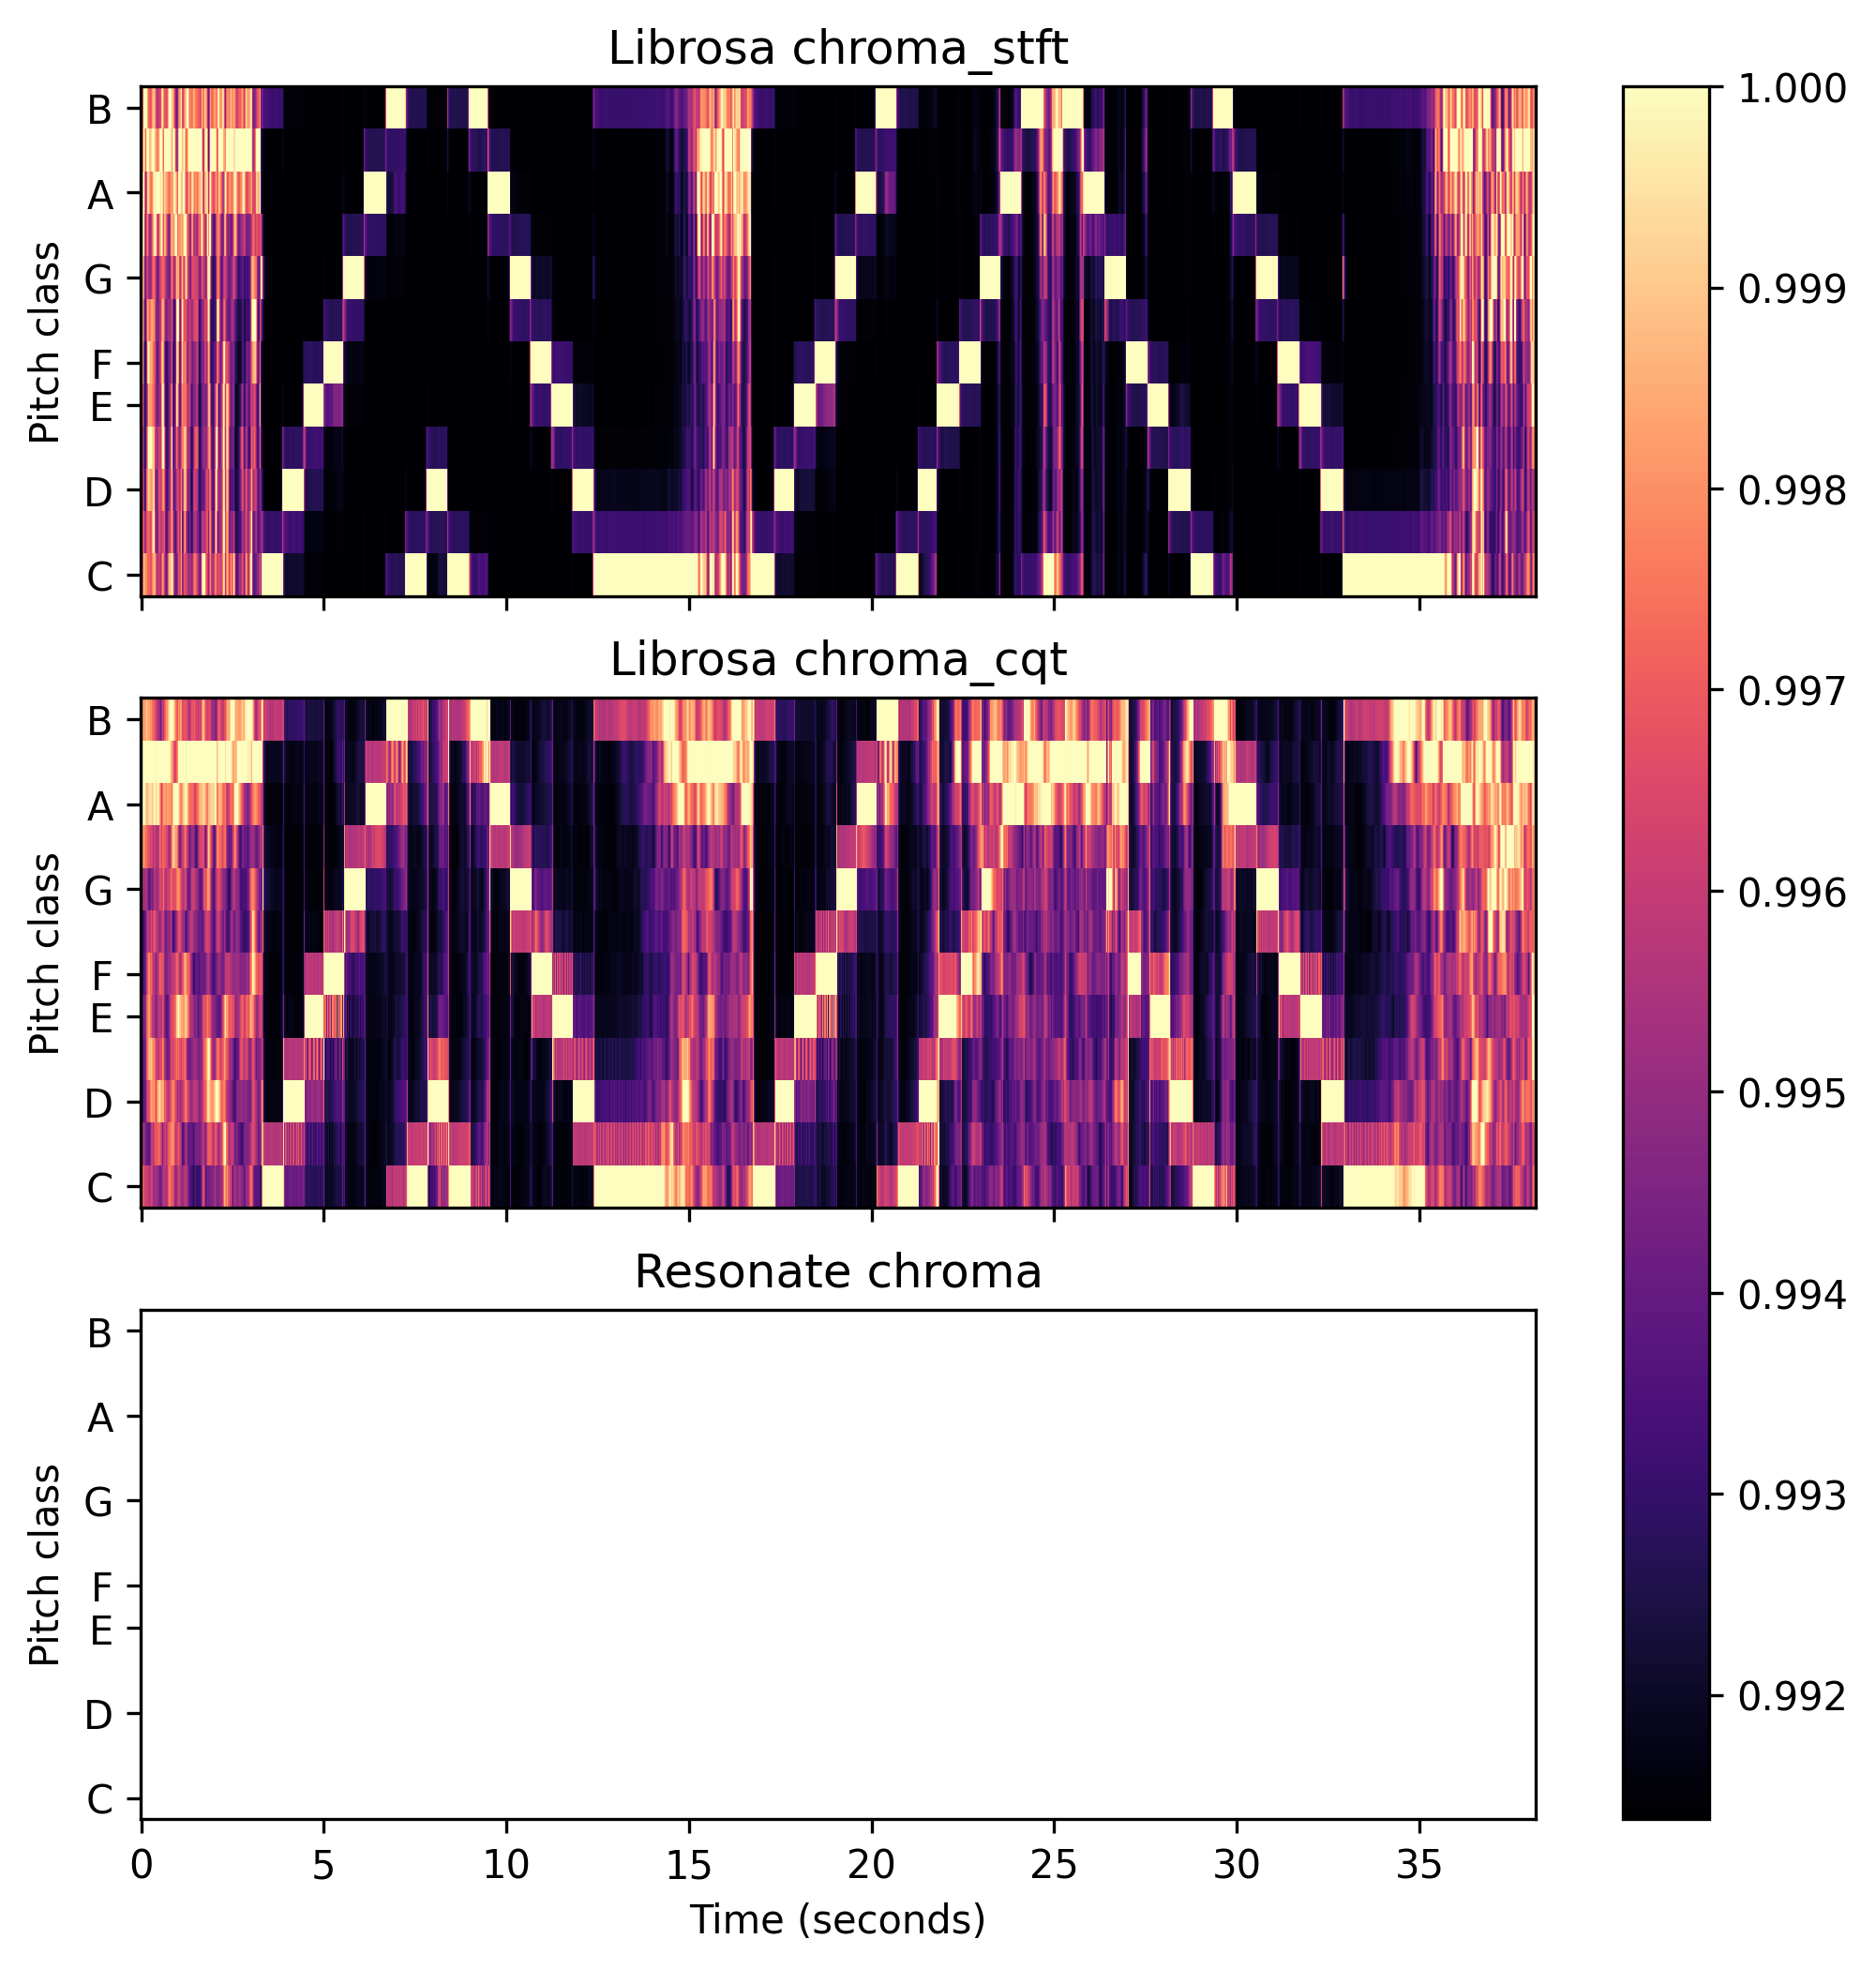

In [153]:
fig, ax = plt.subplots(nrows=3, sharex=True, figsize=(8, 8), dpi=300)
librosa.display.specshow(chroma_stft, hop_length=dhl, y_axis='chroma', x_axis='s', ax=ax[0])
ax[0].set(title='Librosa chroma_stft')
ax[0].label_outer()
img = librosa.display.specshow(chroma_cq, hop_length=dhl, y_axis='chroma', x_axis='s', ax=ax[1])
ax[1].set(title='Librosa chroma_cqt')
ax[1].label_outer()
img = librosa.display.specshow(
    chromaR[:,::dhl],
    sr=sr,
    hop_length=dhl,
    y_axis='chroma',
    x_axis='s',
    ax=ax[2])
ax[2].set(title='Resonate chroma')
fig.colorbar(img, ax=ax)
